# Big Mart Sales Prediction — Standardized ML Pipeline

Predict **Item_Outlet_Sales** (regression) using a clean, leakage-free pipeline.

**Pipeline order:** Basic Analysis -> Train/Test Split -> EDA -> Feature Engineering (incl. missing-value imputation) -> Encoding -> Outlier Handling -> Scaling -> Models.

> This dataset has missing values (`Item_Weight`, `Outlet_Size`). We learn the imputation values (mean / mode) from the **training set only** and apply them to both train and test, so the test set never leaks into training.

## 0. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from scipy import stats
from scipy.stats.mstats import winsorize

sns.set()

## 1. Basic Analysis

Note: `Train.csv` is the labelled file (it contains the target `Item_Outlet_Sales`). The separate `Test.csv` has no target and is only for Kaggle submission, so it is not used here.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Study/Jhankar Mahbub/Phitron ML AI/Main course/ML without git/ML practice self/Machine Learning Projects/Regression/Big Mart sales Prediction/Train.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
print('Shape:', df.shape)
df.info()

Shape: (8523, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [5]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [6]:
# missing values (handled later, using train statistics only)
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


## 2. Train-Test Split (done early to prevent data leakage)

In [7]:
X = df.drop(columns='Item_Outlet_Sales')
y = df['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (6818, 11) | Test: (1705, 11)


## 3. EDA (training data only)

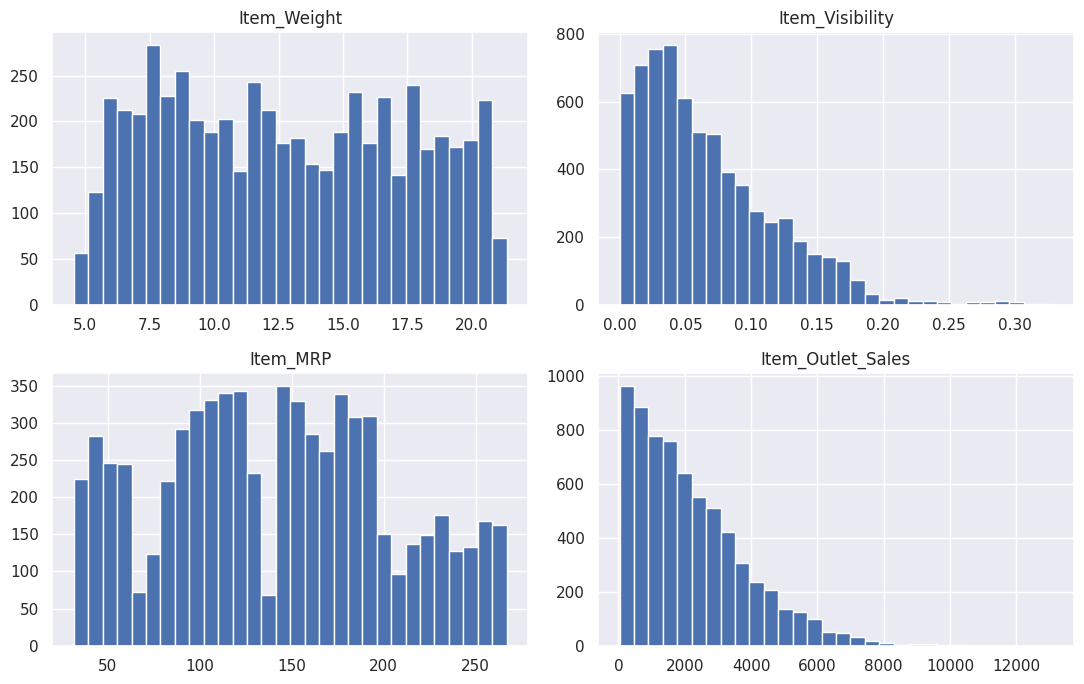

In [8]:
train_df = X_train.copy()
train_df['Item_Outlet_Sales'] = y_train

train_df[['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales']].hist(figsize=(11, 7), bins=30)
plt.tight_layout()
plt.show()

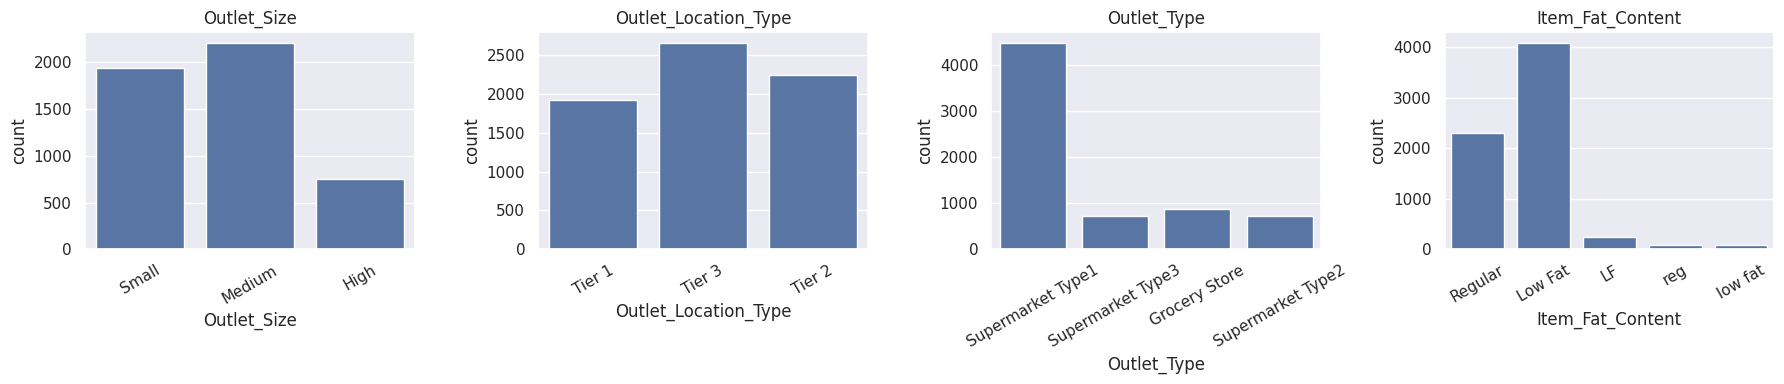

In [9]:
view = ['Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Fat_Content']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, view):
    sns.countplot(x=col, data=train_df, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

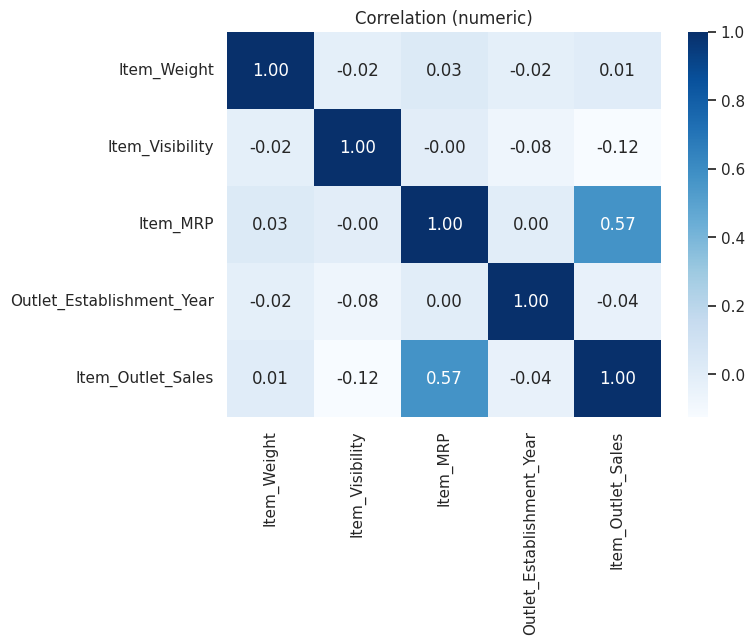

In [10]:
plt.figure(figsize=(7, 5))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation (numeric)')
plt.show()

## 4. Feature Engineering (with train-only missing-value imputation)

- Impute missing `Item_Weight` with the **training mean** and missing `Outlet_Size` with the **training mode**.
- Standardise the messy `Item_Fat_Content` labels (LF / low fat -> Low Fat, reg -> Regular).
- `Item_Category` from the identifier prefix (FD = Food, DR = Drink, NC = Non-Consumable).
- `Outlet_Years` = how long the outlet has operated (2013 − establishment year).

The imputation values come from `X_train` only, then the same function is applied to train and test.

In [11]:
# statistics learned from TRAIN only (no leakage)
item_weight_mean = X_train['Item_Weight'].mean()
outlet_size_mode = X_train['Outlet_Size'].mode()[0]

def add_features(data):
    data = data.copy()
    data['Item_Weight'] = data['Item_Weight'].fillna(item_weight_mean)
    data['Outlet_Size'] = data['Outlet_Size'].fillna(outlet_size_mode)
    data['Item_Fat_Content'] = data['Item_Fat_Content'].replace(
        {'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'})
    data['Item_Category'] = data['Item_Identifier'].str[:2]
    data['Outlet_Years'] = 2013 - data['Outlet_Establishment_Year']
    data = data.drop(columns=['Item_Identifier', 'Outlet_Establishment_Year'])
    return data

X_train = add_features(X_train)
X_test = add_features(X_test)
print('Missing after imputation (train):', int(X_train.isnull().sum().sum()))
X_train.head()

Missing after imputation (train): 0


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Category,Outlet_Years
7173,11.800000,Regular,0.057422,Meat,149.9366,OUT046,Small,Tier 1,Supermarket Type1,FD,16
3315,12.815057,Low Fat,0.000000,Baking Goods,100.1384,OUT027,Medium,Tier 3,Supermarket Type3,FD,28
5932,7.725000,Low Fat,0.047783,Canned,249.1092,OUT046,Small,Tier 1,Supermarket Type1,FD,16
7872,10.500000,Low Fat,0.052555,Frozen Foods,89.6830,OUT046,Small,Tier 1,Supermarket Type1,FD,16
5946,12.815057,Regular,0.235859,Snack Foods,46.1402,OUT019,Small,Tier 1,Grocery Store,FD,28


## 5. Encoding (One-Hot for nominal categoricals)

In [12]:
cat_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
            'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category']

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train = X_train.astype(float)
X_test = X_test.astype(float)
print('Feature count after encoding:', X_train.shape[1])

Feature count after encoding: 38


## 6. Outlier Handling — IQR vs Z-score vs Winsorization (auto-select best)

Applied to the **training set only**, on the continuous columns.

In [13]:
outlier_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP']

def cv_score(Xc, yc):
    model = RandomForestRegressor(n_estimators=100, random_state=2)
    return cross_val_score(model, Xc, yc, cv=5, scoring='r2').mean()

def iqr_clean(X, y, cols):
    mask = pd.Series(True, index=X.index)
    for c in cols:
        q1, q3 = X[c].quantile(0.25), X[c].quantile(0.75)
        iqr = q3 - q1
        mask &= X[c].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return X[mask], y[mask]

def zscore_clean(X, y, cols):
    z = np.abs(stats.zscore(X[cols]))
    mask = (z < 3).all(axis=1)
    return X[mask], y[mask]

def winsor_clean(X, y, cols, limit=0.05):
    Xw = X.copy()
    for c in cols:
        Xw[c] = np.asarray(winsorize(Xw[c], limits=[limit, limit]))
    return Xw, y

scores = {}
scores['none'] = cv_score(X_train, y_train)
scores['iqr'] = cv_score(*iqr_clean(X_train, y_train, outlier_cols))
scores['zscore'] = cv_score(*zscore_clean(X_train, y_train, outlier_cols))
scores['winsorize'] = cv_score(*winsor_clean(X_train, y_train, outlier_cols))

for k, v in scores.items():
    print(f'{k:10s} CV R2: {v:.4f}')

best_outlier = max(scores, key=scores.get)
print('\nBest outlier method:', best_outlier)

none       CV R2: 0.5575
iqr        CV R2: 0.5484
zscore     CV R2: 0.5478
winsorize  CV R2: 0.5564

Best outlier method: none


In [14]:
if best_outlier == 'iqr':
    X_train, y_train = iqr_clean(X_train, y_train, outlier_cols)
elif best_outlier == 'zscore':
    X_train, y_train = zscore_clean(X_train, y_train, outlier_cols)
elif best_outlier == 'winsorize':
    X_train, y_train = winsor_clean(X_train, y_train, outlier_cols)

print('Training rows after outlier handling:', X_train.shape[0])

Training rows after outlier handling: 6818


## 7. Feature Scaling — Standard vs MinMax vs Robust (auto-select best)

In [15]:
scalers = {'standard': StandardScaler(), 'minmax': MinMaxScaler(), 'robust': RobustScaler()}

scaler_scores = {}
for name, sc in scalers.items():
    X_scaled = sc.fit_transform(X_train)
    scaler_scores[name] = cross_val_score(KNeighborsRegressor(), X_scaled, y_train, cv=5, scoring='r2').mean()
    print(f'{name:10s} CV R2 (KNN): {scaler_scores[name]:.4f}')

best_scaler_name = max(scaler_scores, key=scaler_scores.get)
print('\nBest scaler:', best_scaler_name)

scaler = scalers[best_scaler_name]
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

standard   CV R2 (KNN): 0.4464
minmax     CV R2 (KNN): 0.4584
robust     CV R2 (KNN): 0.4827

Best scaler: robust


## 8. Model Training & Comparison

In [16]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=2),
    'Gradient Boosting': GradientBoostingRegressor(random_state=2),
    'KNN': KNeighborsRegressor(),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

,Model,R2,MAE,RMSE
0,Gradient Boosting,0.579916,799.747840,1138.784305
1,Random Forest,0.549573,824.988188,1179.195805
2,Linear Regression,0.544530,875.513544,1185.778487
3,KNN,0.486101,902.233351,1259.542001


In [17]:
best_row = results_df.iloc[0]
print('Best model :', best_row['Model'])
print('Test R2    :', round(best_row['R2'], 4))
print('Test MAE   :', round(best_row['MAE'], 2))
print('Test RMSE  :', round(best_row['RMSE'], 2))

Best model : Gradient Boosting
Test R2    : 0.5799
Test MAE   : 799.75
Test RMSE  : 1138.78
